In [1]:
import pandas as pd
df = pd.read_csv('C:/Users/Dianalaura Cueto/Electricity Prices Forecast/data/Raw/PrecioNodoBajaCalifornia.csv',skiprows=7)

#Rows -1 = Zonas de carga data

In [2]:
print(df.shape)
print(df.head())

(96, 6)
   Hora  Zona de Carga   Precio Zonal ($/MWh)   Componente energia ($/MWh)  \
0     1       ENSENADA                 299.90                       291.40   
1     2       ENSENADA                 285.83                       278.84   
2     3       ENSENADA                 255.80                       249.37   
3     4       ENSENADA                 243.98                       237.78   
4     5       ENSENADA                 165.05                       160.42   

    Componente perdidas ($/MWh)   Componente Congestion ($/MWh)  
0                          8.51                               0  
1                          6.99                               0  
2                          6.42                               0  
3                          6.20                               0  
4                          4.63                               0  


In [3]:
print(df.columns.tolist())

['Hora', ' Zona de Carga', ' Precio Zonal ($/MWh)', ' Componente energia ($/MWh)', ' Componente perdidas ($/MWh)', ' Componente Congestion ($/MWh)']


In [4]:
df.columns = df.columns.str.strip() #erase initial blank spaces
print(df.columns.tolist())

['Hora', 'Zona de Carga', 'Precio Zonal ($/MWh)', 'Componente energia ($/MWh)', 'Componente perdidas ($/MWh)', 'Componente Congestion ($/MWh)']


In [5]:
print(df.dtypes) #check types of data in columns for energia we want float64 

Hora                               int64
Zona de Carga                        str
Precio Zonal ($/MWh)             float64
Componente energia ($/MWh)       float64
Componente perdidas ($/MWh)      float64
Componente Congestion ($/MWh)      int64
dtype: object


In [6]:
#convert all columns except zona de carga to float
df["Zona de Carga"]=df["Zona de Carga"].astype(str)
df["Hora"]=df["Hora"].astype(int)
colstype_convert = [col for col in df.columns if col not in ['Zona de Carga', 'Hora']]
df[colstype_convert]= df[colstype_convert].astype(float)
print(df.dtypes)

Hora                               int64
Zona de Carga                        str
Precio Zonal ($/MWh)             float64
Componente energia ($/MWh)       float64
Componente perdidas ($/MWh)      float64
Componente Congestion ($/MWh)    float64
dtype: object


In [7]:
#Checking for null and duplicates in a function.
#Automatically drops exact duplicate rows.
   

def clean_dataframe(df):
    
    print("=== Null values per column ===")
    print(df.isnull().sum())

    dup_count = df.duplicated().sum()
    print(f"\n=== Duplicate rows found: {dup_count} ===")

    if dup_count > 0:
        df = df.drop_duplicates()
        print("Duplicates removed.")
    else:
        print("No duplicates to remove.")

    return df
    

In [8]:
df = clean_dataframe(df)

=== Null values per column ===
Hora                             0
Zona de Carga                    0
Precio Zonal ($/MWh)             0
Componente energia ($/MWh)       0
Componente perdidas ($/MWh)      0
Componente Congestion ($/MWh)    0
dtype: int64

=== Duplicate rows found: 0 ===
No duplicates to remove.


In [9]:
zonas=df["Zona de Carga"].unique()  # Numero de zonas de carga/ No. of zonas de carga
print(zonas)

<StringArray>
['ENSENADA', 'MEXICALI', 'SANLUIS', 'TIJUANA']
Length: 4, dtype: str


In [10]:
df["Hora"].min(), df["Hora"].max() # check hour range


(np.int64(1), np.int64(24))

In [11]:
#export to csv
df.to_csv("C:/Users/Dianalaura Cueto/Electricity Prices Forecast/data/Clean/PrecioNodoBajaCalifornia_clean.csv", index=False, encoding='utf-8-sig')


In [12]:
rows = df.loc[ df['Precio Zonal ($/MWh)'].idxmax(), ['Zona de Carga', 'Hora']]

In [13]:
Highest=print(rows) # Zona de carga with the higest electricity price

Zona de Carga    SANLUIS
Hora                  20
Name: 67, dtype: object


In [14]:
row = df.loc[ df['Precio Zonal ($/MWh)'].idxmin(), ['Zona de Carga', 'Hora']]

In [15]:
Lowest=print(row)

Zona de Carga    MEXICALI
Hora                    7
Name: 30, dtype: object


In [16]:
meanprice= df.groupby('Zona de Carga')['Precio Zonal ($/MWh)'].mean() # group each zone , average their precio zonal and prints the zone with the higest price and the price
max_meanprice= meanprice.idxmax()
value_maxmean= meanprice.max()
maximo=print(max_meanprice)
print(value_maxmean)

ENSENADA
287.79249999999996


In [17]:
!pip install matplotlib


#This function creates individual plots for Zona de Carga via input 


import matplotlib.pyplot as plt
def inter_zone(df):

     Zona =input("Enter name of Zona de carga to plot (in all CAPS):") # write a zone of interest and plot the hourly price
     df_filterzone = df[df["Zona de Carga"] == Zona]
     df_filterzone.plot(x='Hora', y='Precio Zonal ($/MWh)', kind='line', marker='o', color='blue', figsize=(10, 5))
     plt.title(f"{Zona} HOURLY PRICES")
     plt.xlabel('Time (HR)')
     plt.ylabel('Price ($/MWh)')
     plt.grid(True)
     plt.show()
     return df



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\Dianalaura Cueto\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [18]:
#df_filter= inter_zone(df)  # Uncomment to request via input individual plots

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\Dianalaura Cueto\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


Index(['Hora', 'Zona de Carga', 'Precio Zonal ($/MWh)',
       'Componente energia ($/MWh)', 'Componente perdidas ($/MWh)',
       'Componente Congestion ($/MWh)'],
      dtype='str')


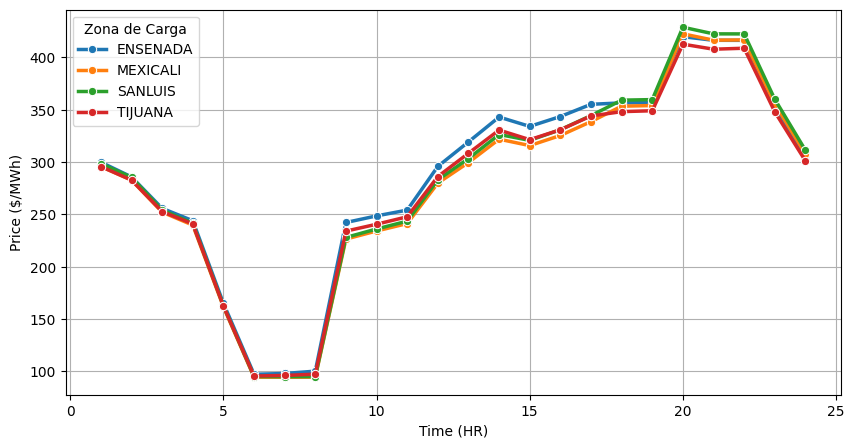

In [19]:
#plot all
%pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns #need seaborn to filter zones in an easy way adding a 3rd dimension but just plot 2 dimensions
print(df.columns)
plt.figure(figsize=(10, 5))
sns.lineplot(df,x='Hora', y='Precio Zonal ($/MWh)', hue='Zona de Carga', marker='o', linewidth=2.5) # "hue" filters the unique zones in  Zona de Carga
plt.xlabel('Time (HR)')
plt.ylabel('Price ($/MWh)')
plt.grid(True)
plt.show()